In [3]:
import sys
sys.path.append("src")

import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import quantum_algorithms as qa

In [4]:
# Experiment settings

shots = 1024
n_values = [1, 3, 5, 7, 9]
theta_values = np.radians(np.arange(0, 181, 10))

axes = {
    "X": (1, 0, 0),
    "Y": (0, 1, 0),
    "Z": (0, 0, 1),
}

functions = {
    "constant_1": qa.deutsch_jozsa.f_constant_1,
    "constant_0": qa.deutsch_jozsa.f_constant_0,
    "balanced": qa.deutsch_jozsa.f_balanced_parity,
}

error_positions = {
    "E1_before_H": qa.deutsch_jozsa.deutsch_jozsa_error1,
    "E2_after_first_H": qa.deutsch_jozsa.deutsch_jozsa_error2,
    "E3_after_oracle": qa.deutsch_jozsa.deutsch_jozsa_error3,
    "E4_after_final_H": qa.deutsch_jozsa.deutsch_jozsa_error4,
}

In [5]:
# Run simulation with shots


results = []
for n in n_values:
    print("Running n =", n)

    target_qubit = n // 2

    for function_name, f in functions.items():

        # Original DJA without error
        state_ref = qa.deutsch_jozsa.deutsch_jozsa(n, f)
        samples_ref = qa.deutsch_jozsa.sample_measurements_input(
            state_ref, n, shots
        )

        P0_ref = samples_ref[0] / shots

        for theta in theta_values:
            for axis_name, axis in axes.items():

                results.append({
                    "n": n,
                    "theta_rad": theta,
                    "theta_deg": np.degrees(theta),
                    "axis": axis_name,
                    "target_qubit": target_qubit,
                    "function": function_name,
                    "error_position": "no_error",
                    "P0": P0_ref,
                    "shots": shots,
                })

                # E1, E2, E3, E4
                for error_name, error_function in error_positions.items():

                    state_error = error_function(
                        n, f, theta, target_qubit, axis
                    )

                    samples_error = qa.deutsch_jozsa.sample_measurements_input(
                        state_error, n, shots
                    )

                    P0_error = samples_error[0] / shots

                    results.append({
                        "n": n,
                        "theta_rad": theta,
                        "theta_deg": np.degrees(theta),
                        "axis": axis_name,
                        "target_qubit": target_qubit,
                        "function": function_name,
                        "error_position": error_name,
                        "P0": P0_error,
                        "shots": shots,
                    })

df = pd.DataFrame(results)

df.head()

Running n = 1
Running n = 3
Running n = 5
Running n = 7
Running n = 9


,n,theta_rad,theta_deg,axis,target_qubit,function,error_position,P0,shots
0,1,0.0,0.0,X,0,constant_1,no_error,1.0,1024
1,1,0.0,0.0,X,0,constant_1,E1_before_H,1.0,1024
2,1,0.0,0.0,X,0,constant_1,E2_after_first_H,1.0,1024
3,1,0.0,0.0,X,0,constant_1,E3_after_oracle,1.0,1024
4,1,0.0,0.0,X,0,constant_1,E4_after_final_H,1.0,1024


In [ ]:
# Save results
df.to_csv("dja_error_results_shots_1024.csv", index=False)

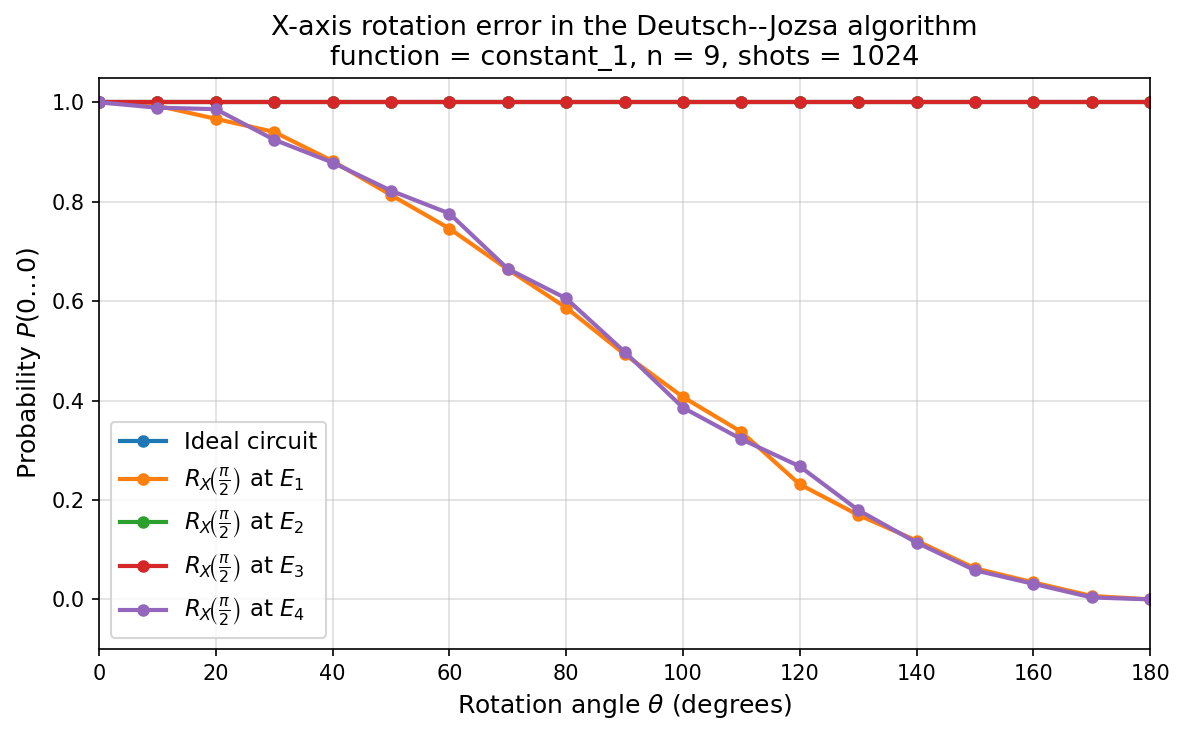

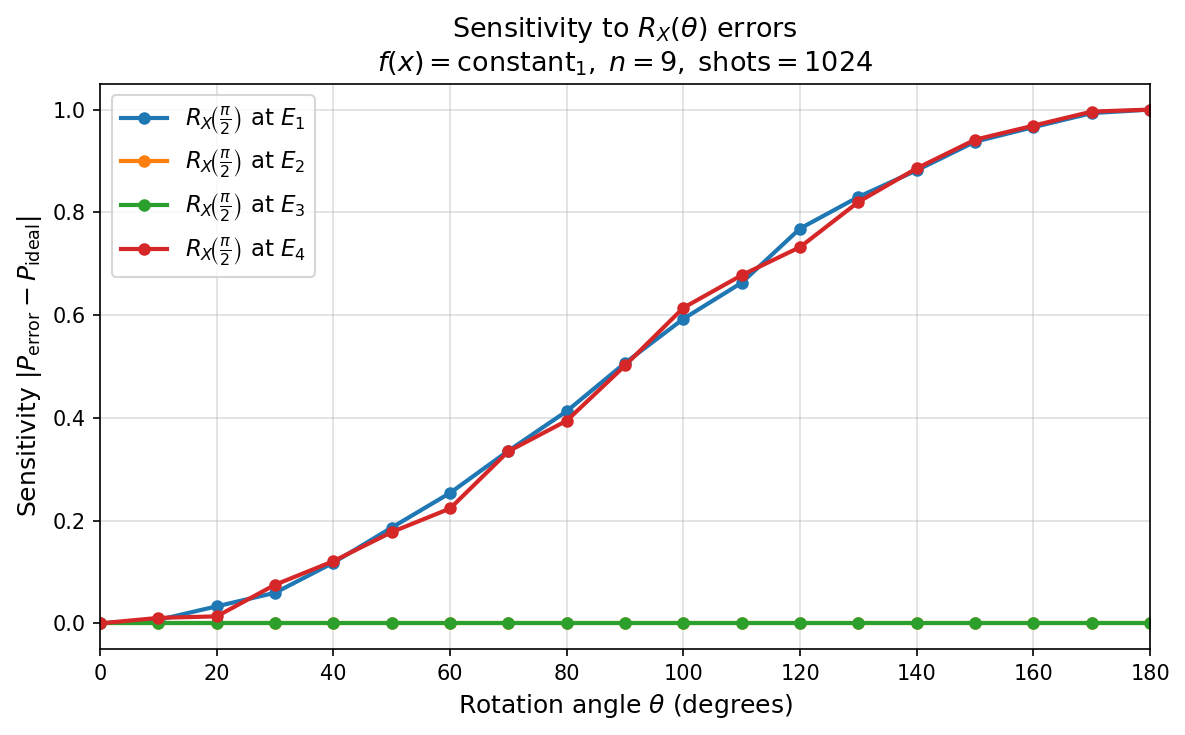

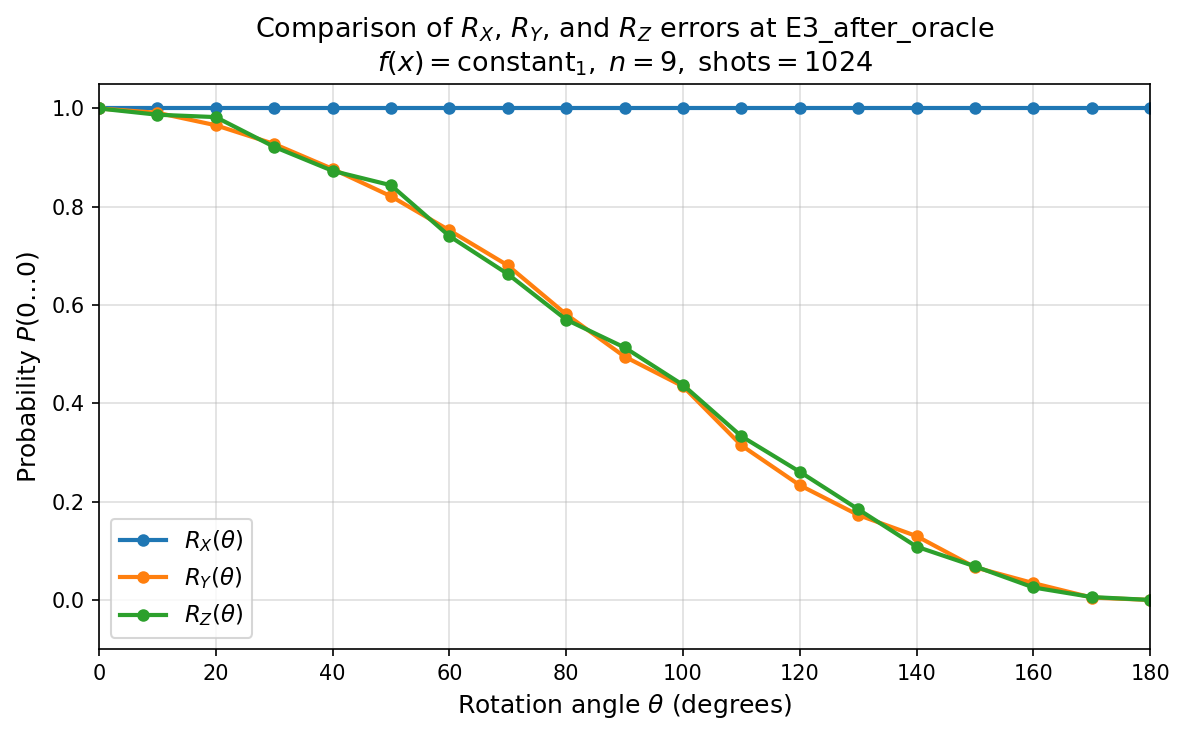

In [6]:
qa.plotting.plot_error_positions(
    df,
    n_plot=9,
    axis_plot="X",
    function_plot="constant_1",
    shots=shots
)

qa.plotting.plot_sensitivity(
    df,
    n_plot=9,
    axis_plot="X",
    function_plot="constant_1",
    shots=shots
)

qa.plotting.plot_axis_comparison(
    df,
    n_plot=9,
    function_plot="constant_1",
    error_position="E3_after_oracle",
    shots=shots
)

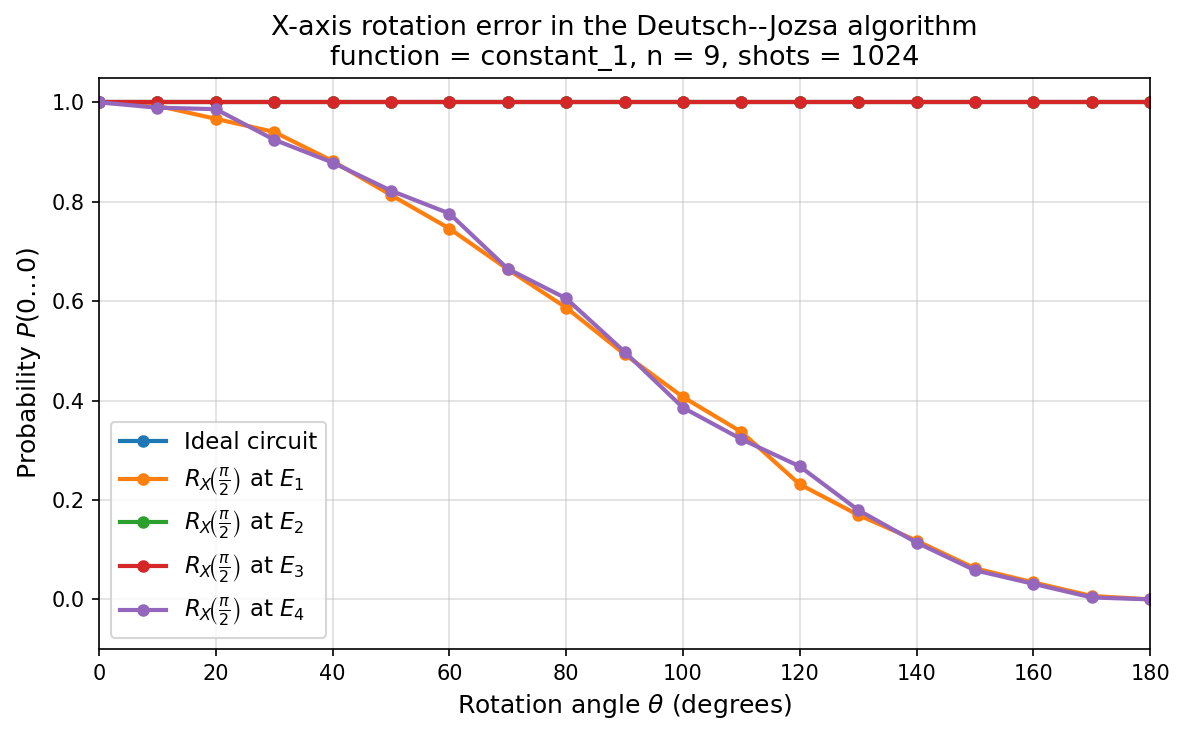

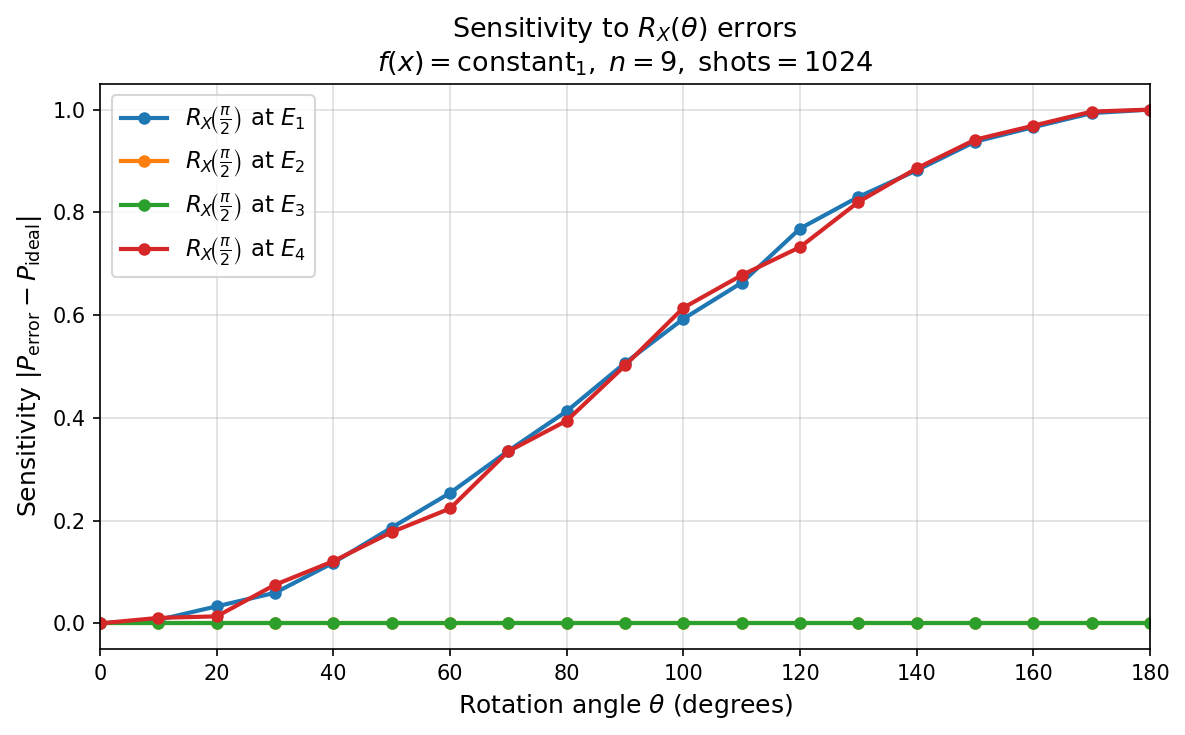

In [7]:
qa.plotting.plot_error_positions(
    df,
    n_plot=9,
    axis_plot="X",
    function_plot="constant_1",
    shots=shots
)

qa.plotting.plot_sensitivity(
    df,
    n_plot=9,
    axis_plot="X",
    function_plot="constant_1",
    shots=shots
)

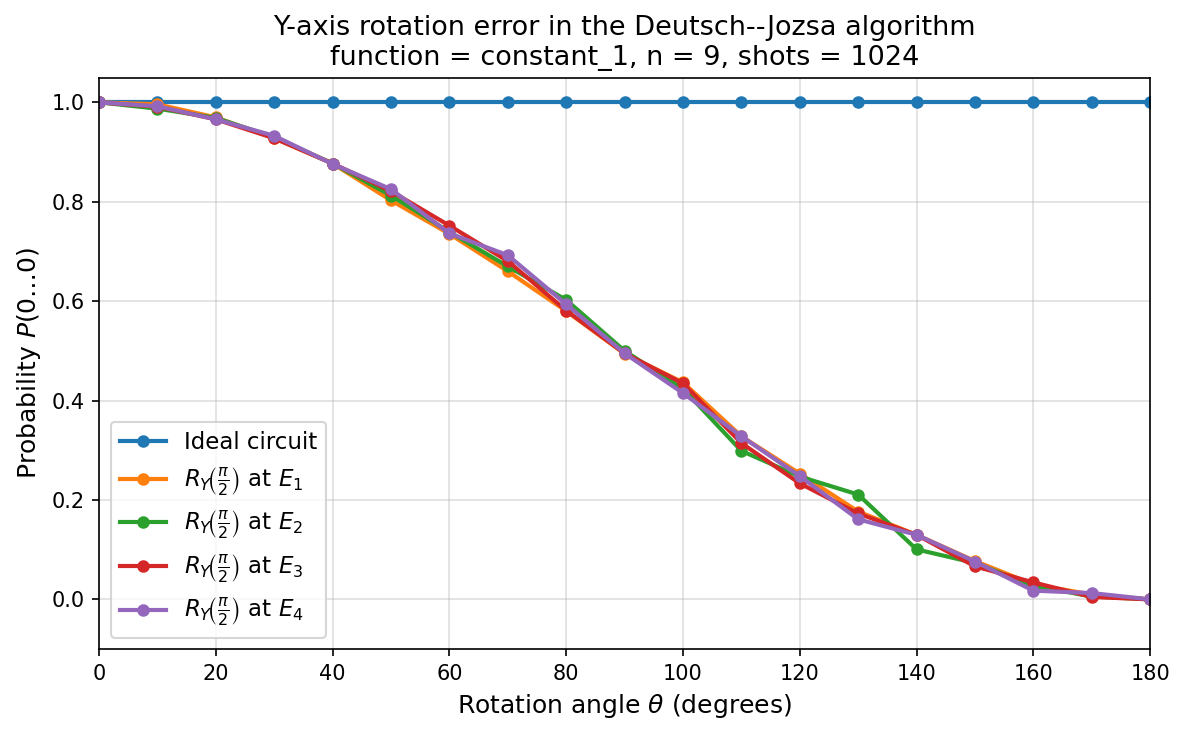

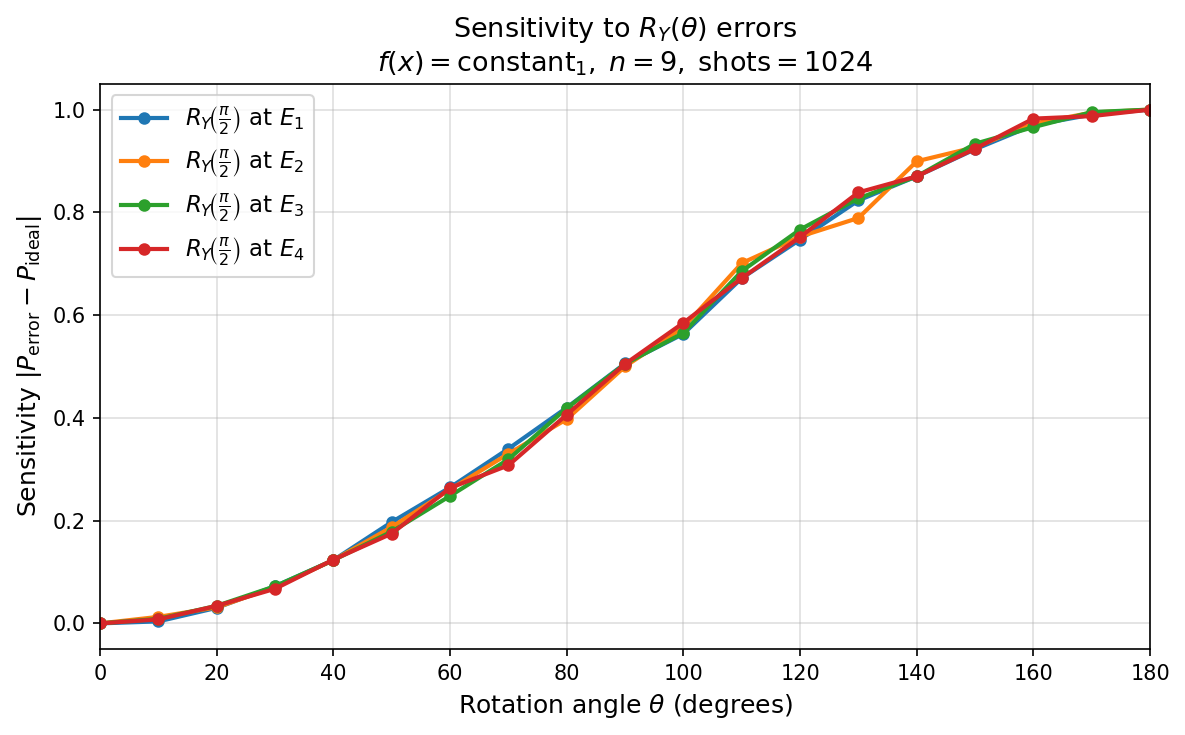

In [8]:
qa.plotting.plot_error_positions(
    df,
    n_plot=9,
    axis_plot="Y",
    function_plot="constant_1",
    shots=shots
)

qa.plotting.plot_sensitivity(
    df,
    n_plot=9,
    axis_plot="Y",
    function_plot="constant_1",
    shots=shots
)

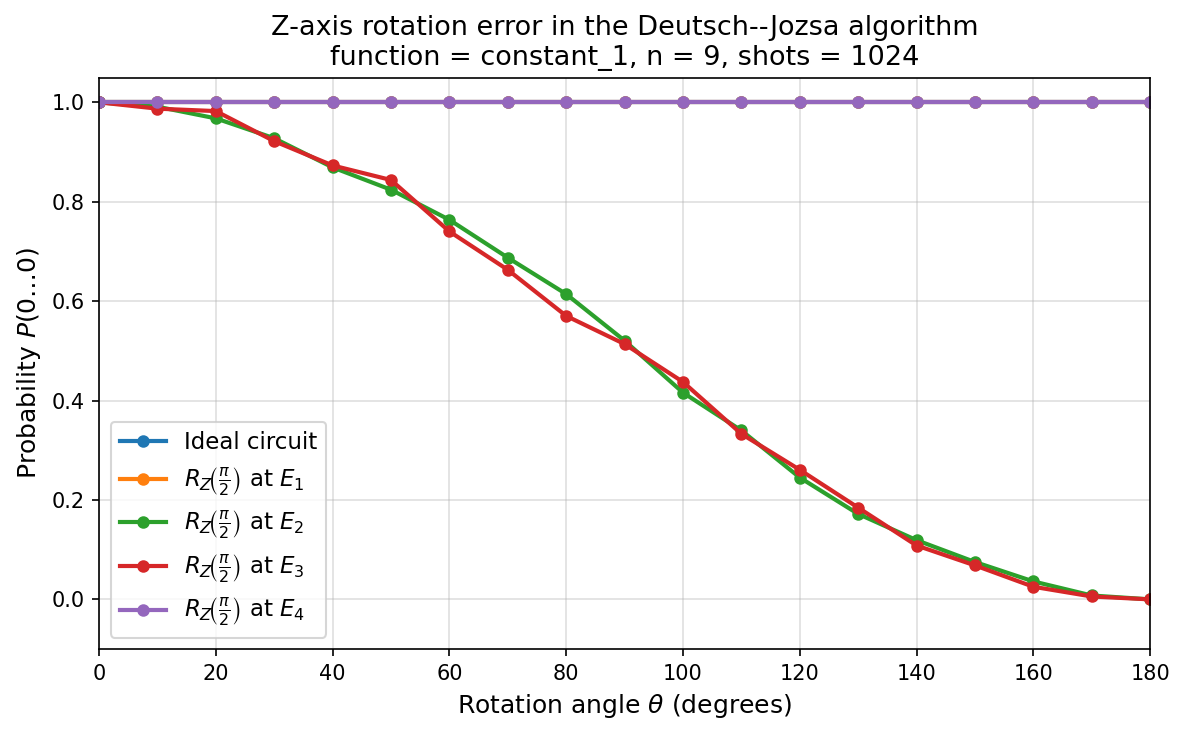

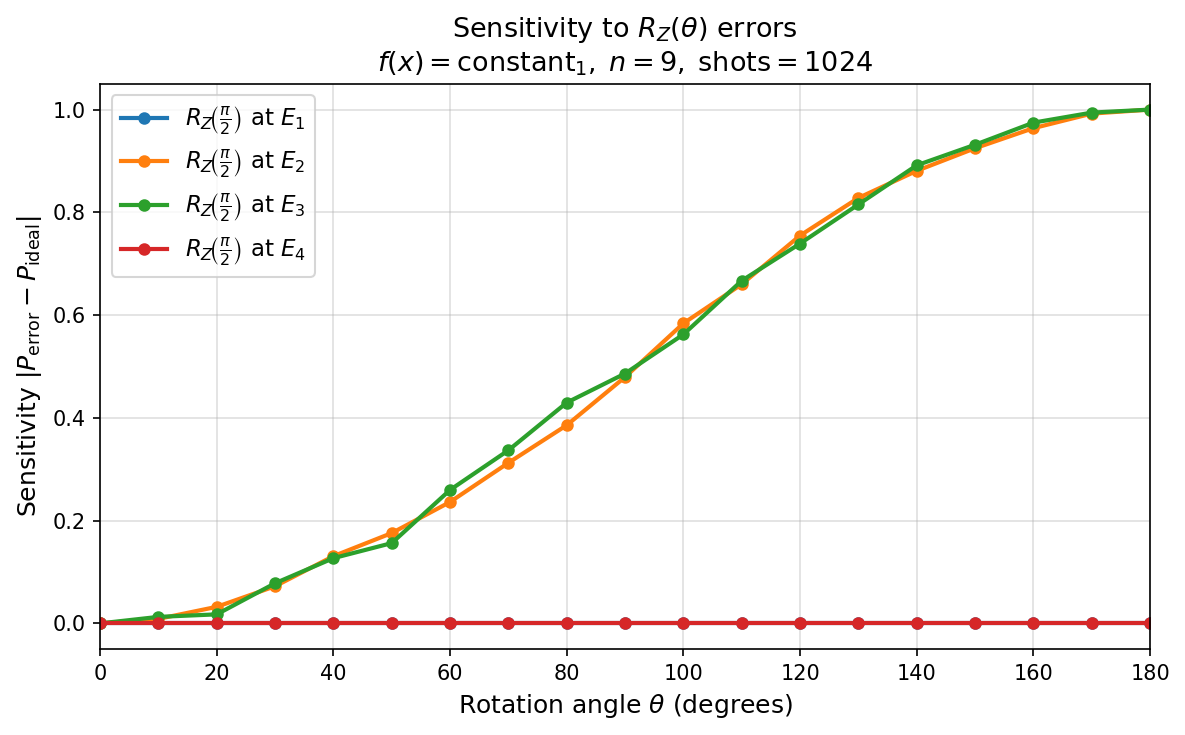

In [9]:

qa.plotting.plot_error_positions(
    df,
    n_plot=9,
    axis_plot="Z",
    function_plot="constant_1",
    shots=shots
)

qa.plotting.plot_sensitivity(
    df,
    n_plot=9,
    axis_plot="Z",
    function_plot="constant_1",
    shots=shots
)

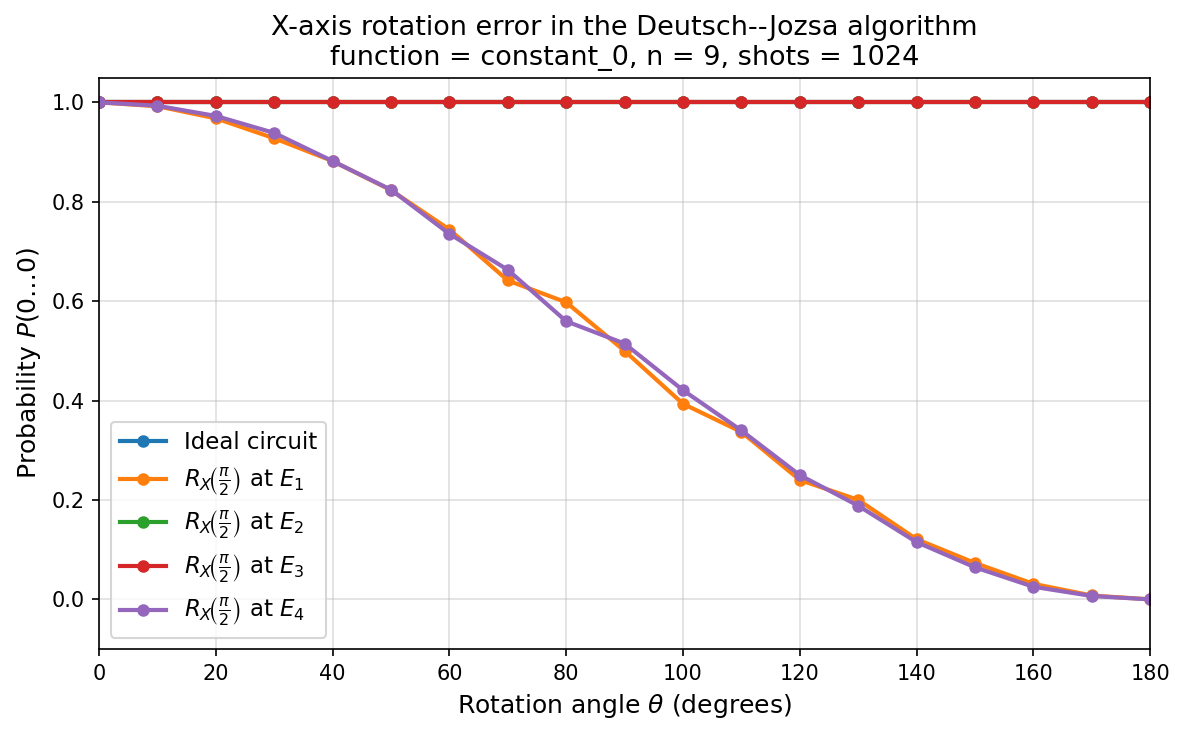

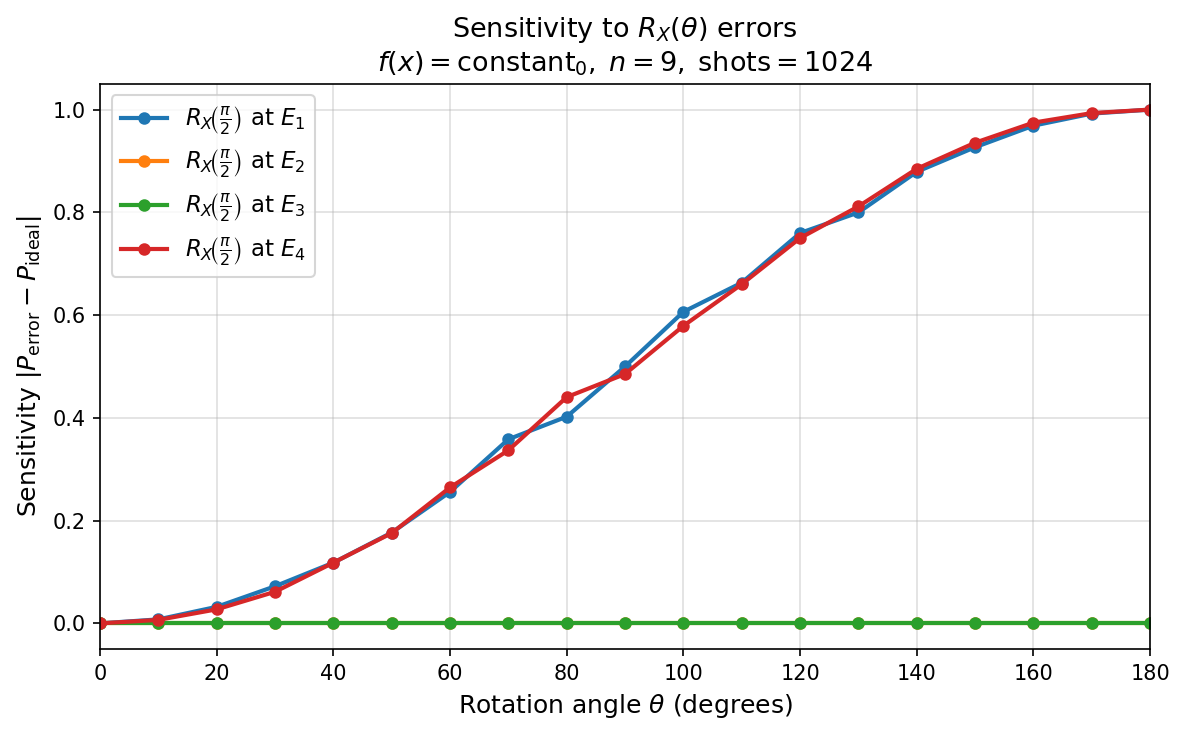

In [11]:
qa.plotting.plot_error_positions(
    df,
    n_plot=9,
    axis_plot="X",
    function_plot="constant_0",
    shots=shots
)

qa.plotting.plot_sensitivity(
    df,
    n_plot=9,
    axis_plot="X",
    function_plot="constant_0",
    shots=shots
)


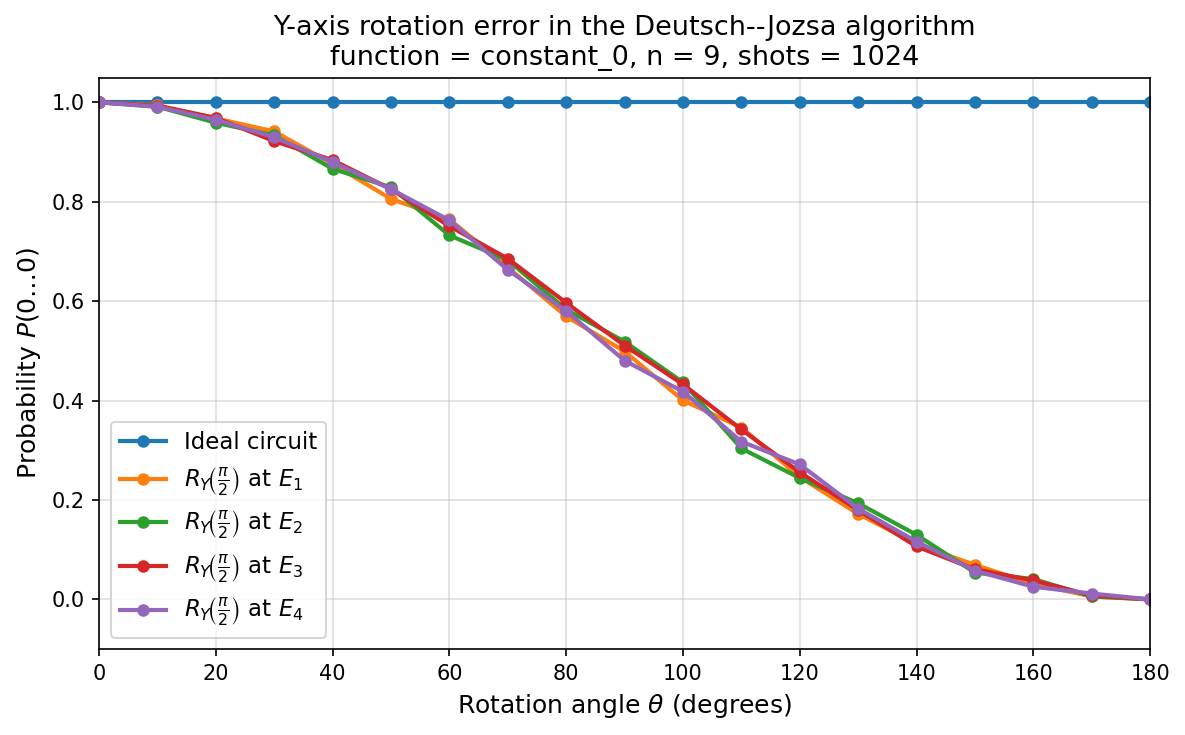

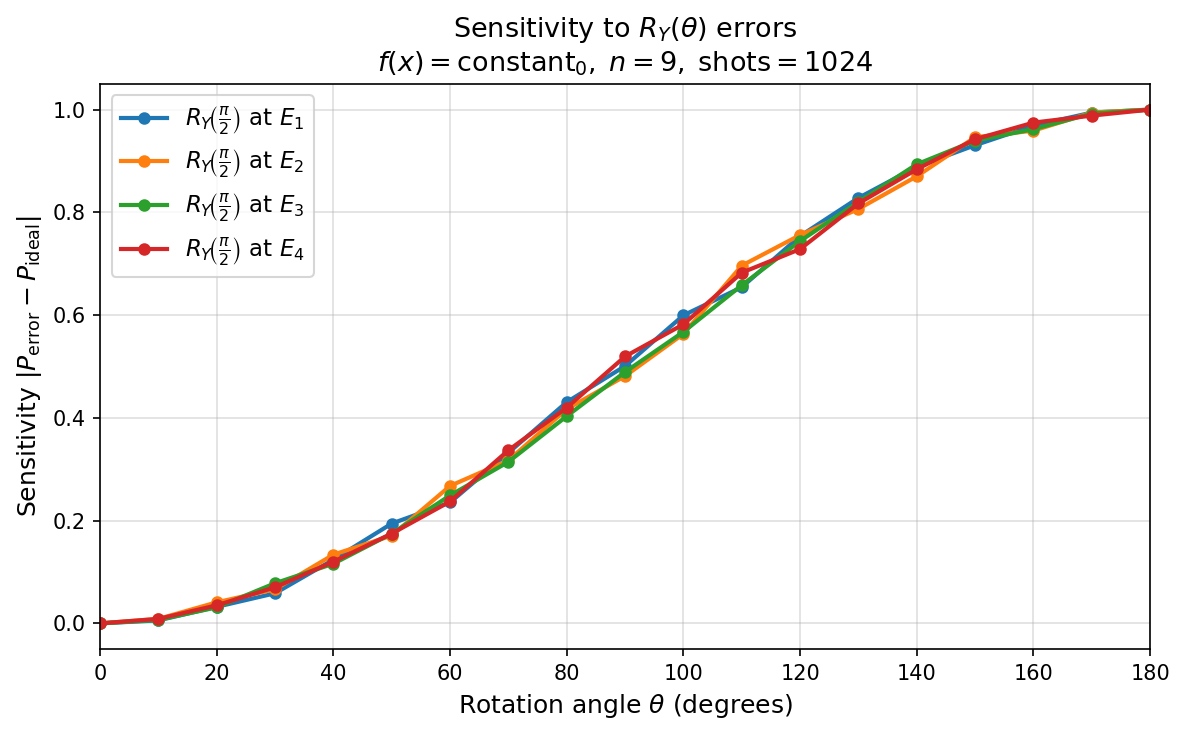

In [12]:
qa.plotting.plot_error_positions(
    df,
    n_plot=9,
    axis_plot="Y",
    function_plot="constant_0",
    shots=shots
)

qa.plotting.plot_sensitivity(
    df,
    n_plot=9,
    axis_plot="Y",
    function_plot="constant_0",
    shots=shots
)


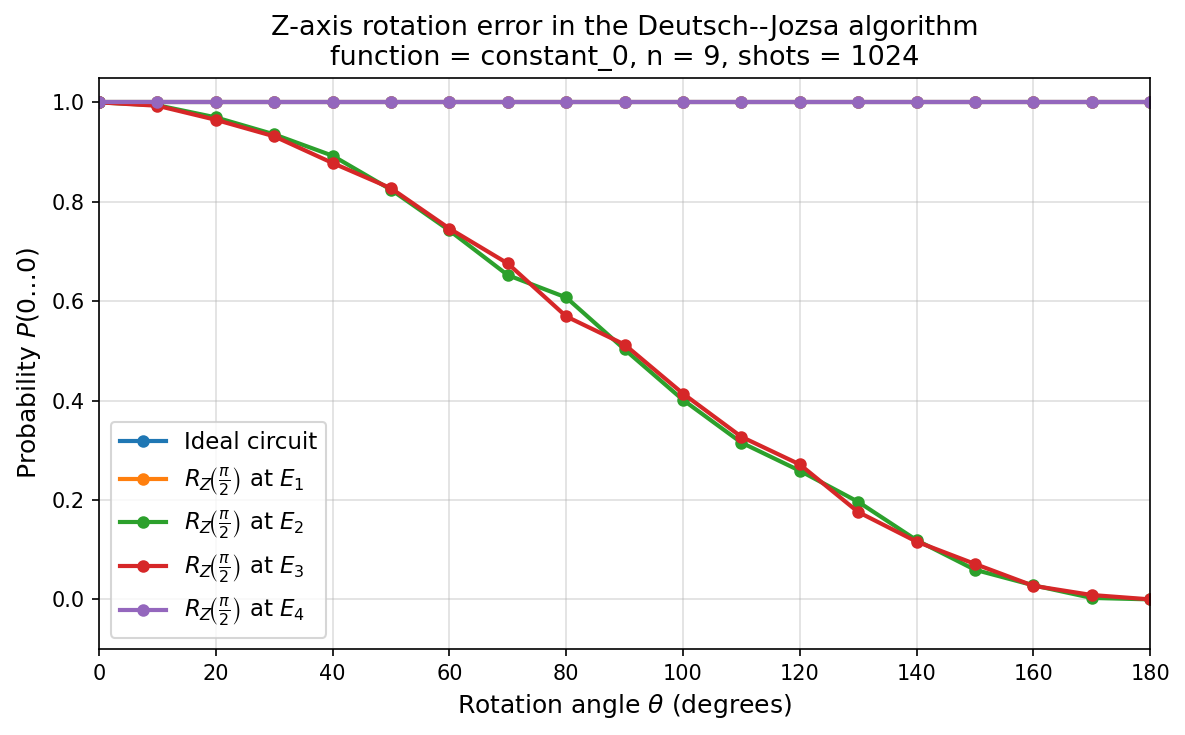

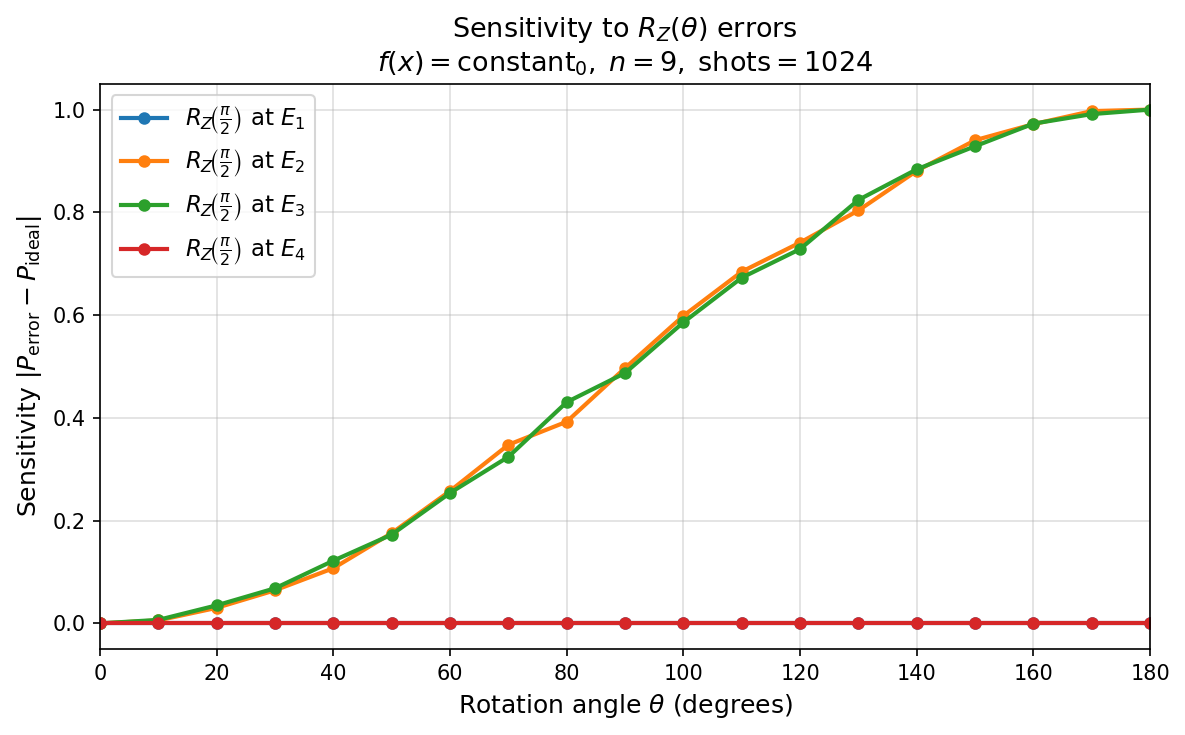

In [13]:
qa.plotting.plot_error_positions(
    df,
    n_plot=9,
    axis_plot="Z",
    function_plot="constant_0",
    shots=shots
)

qa.plotting.plot_sensitivity(
    df,
    n_plot=9,
    axis_plot="Z",
    function_plot="constant_0",
    shots=shots
)

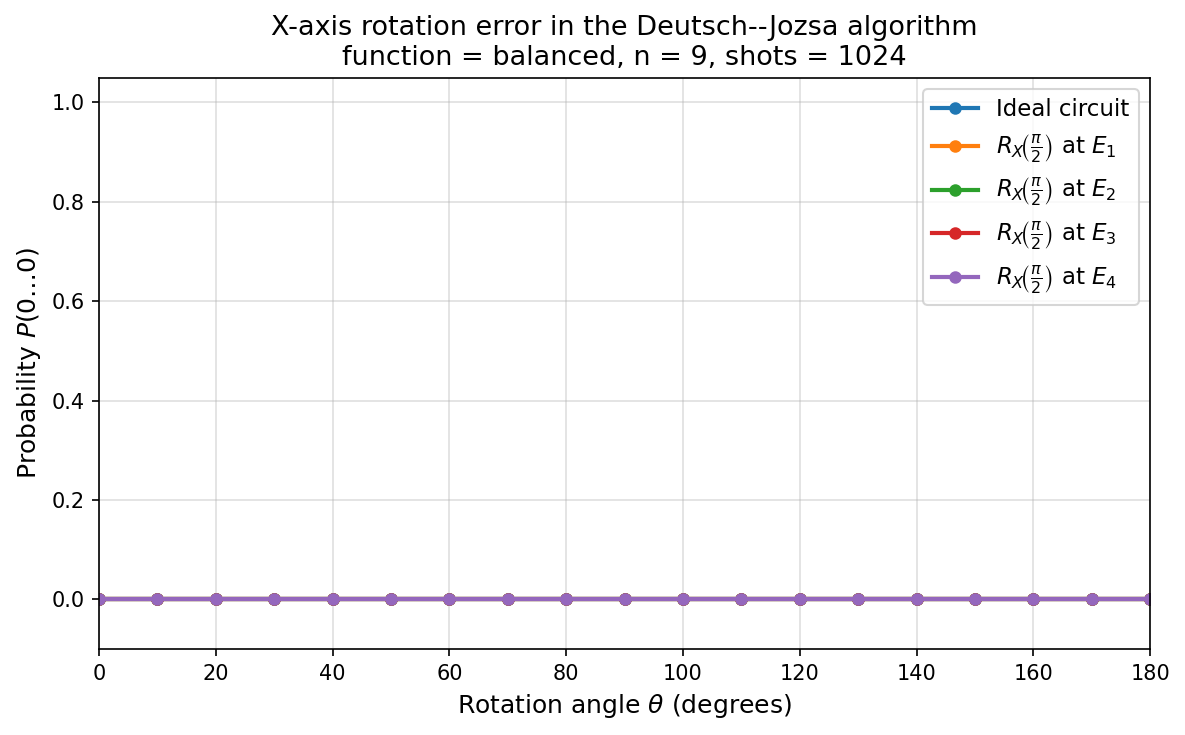

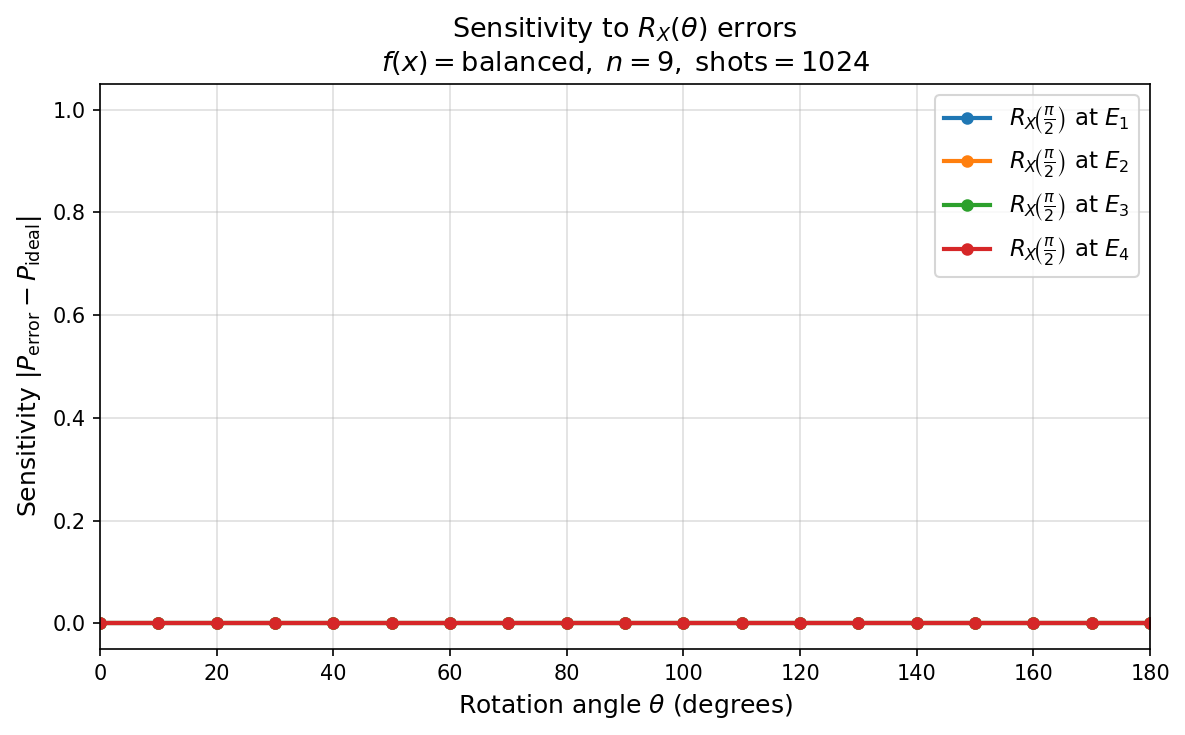

In [14]:
qa.plotting.plot_error_positions(
    df,
    n_plot=9,
    axis_plot="X",
    function_plot="balanced",
    shots=shots
)

qa.plotting.plot_sensitivity(
    df,
    n_plot=9,
    axis_plot="X",
    function_plot="balanced",
    shots=shots
)

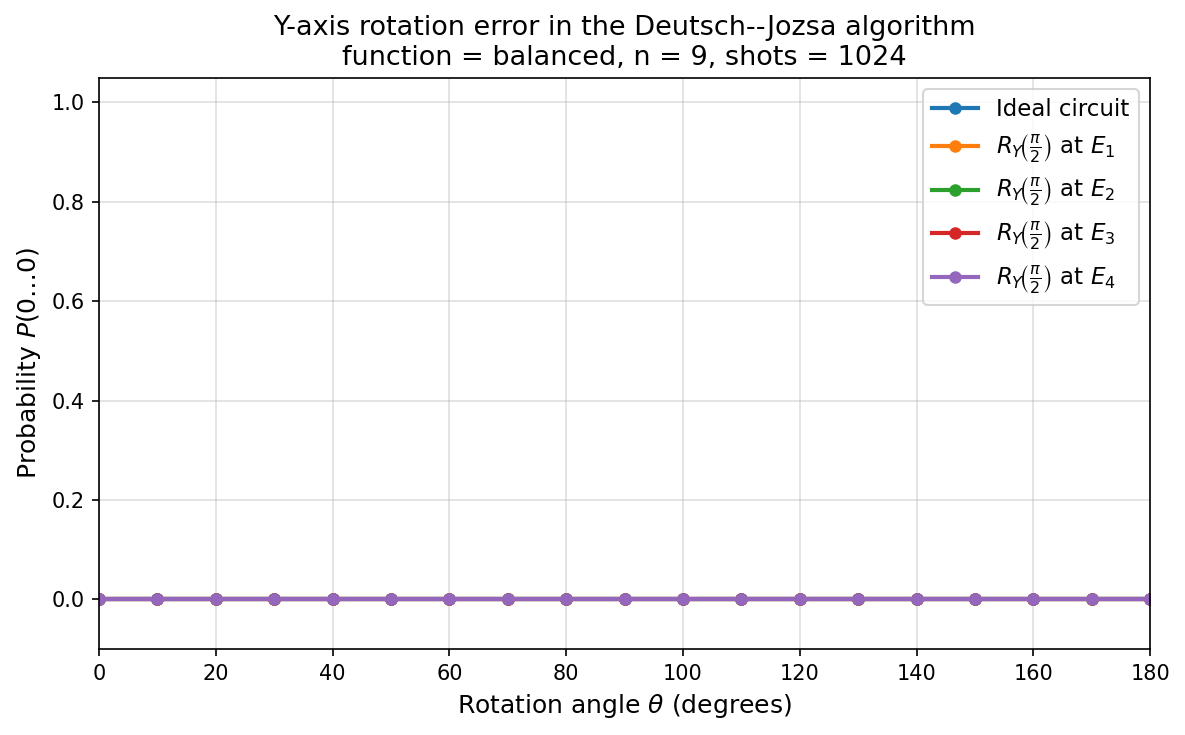

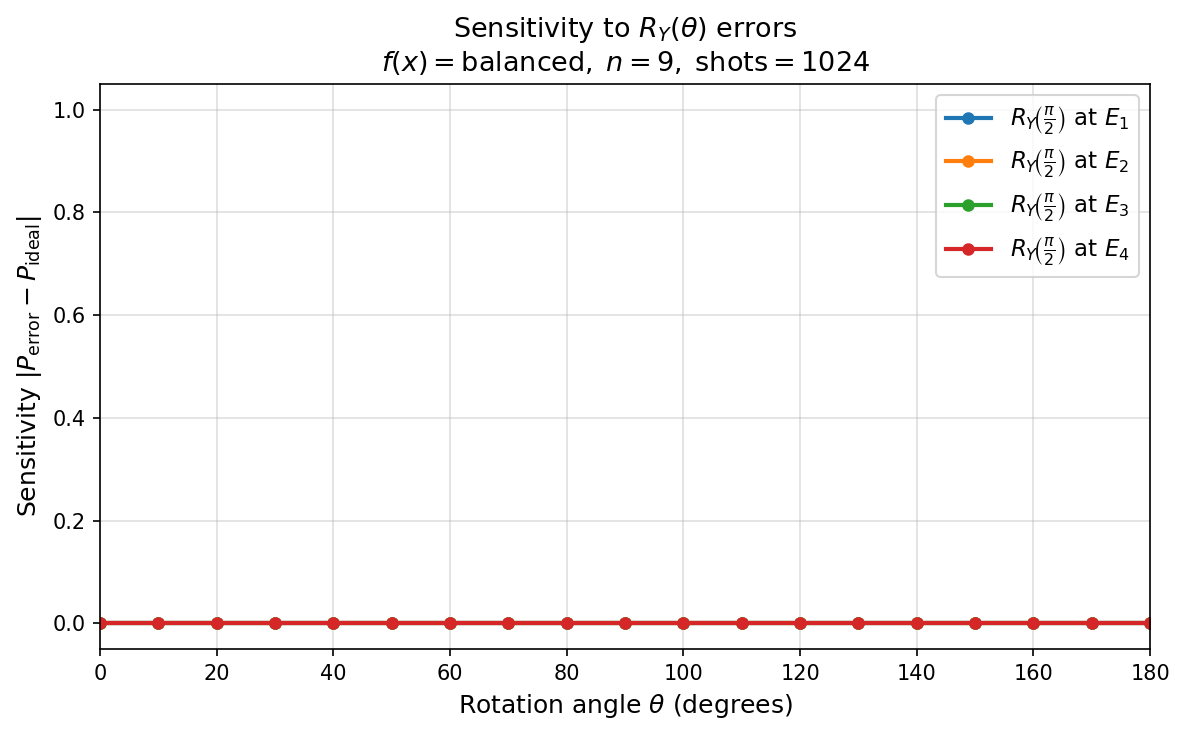

In [15]:
qa.plotting.plot_error_positions(
    df,
    n_plot=9,
    axis_plot="Y",
    function_plot="balanced",
    shots=shots
)

qa.plotting.plot_sensitivity(
    df,
    n_plot=9,
    axis_plot="Y",
    function_plot="balanced",
    shots=shots
)

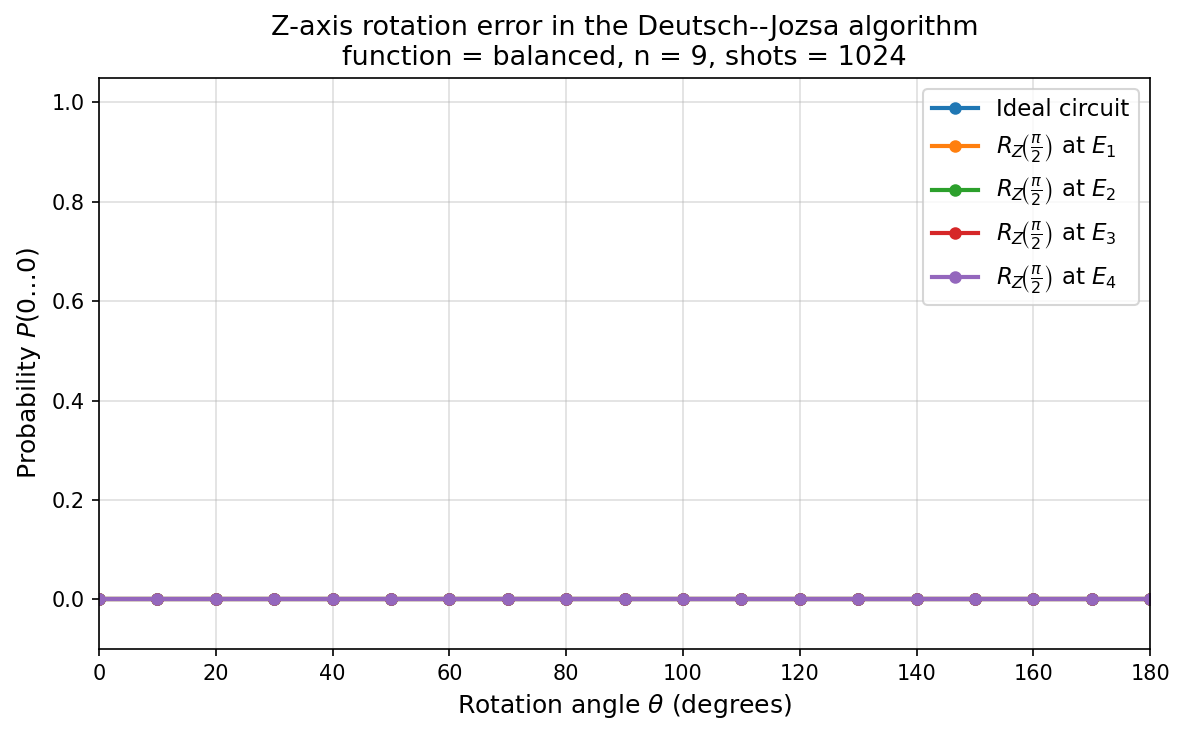

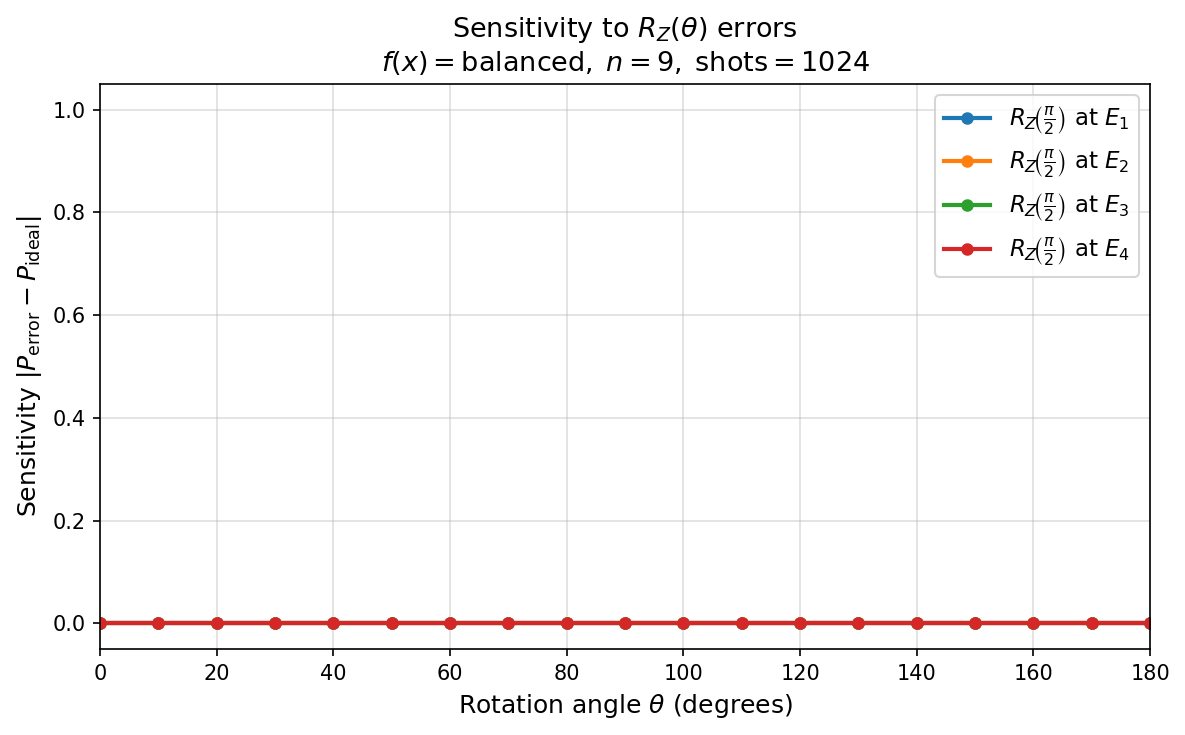

In [16]:
qa.plotting.plot_error_positions(
    df,
    n_plot=9,
    axis_plot="Z",
    function_plot="balanced",
    shots=shots
)

qa.plotting.plot_sensitivity(
    df,
    n_plot=9,
    axis_plot="Z",
    function_plot="balanced",
    shots=shots
)

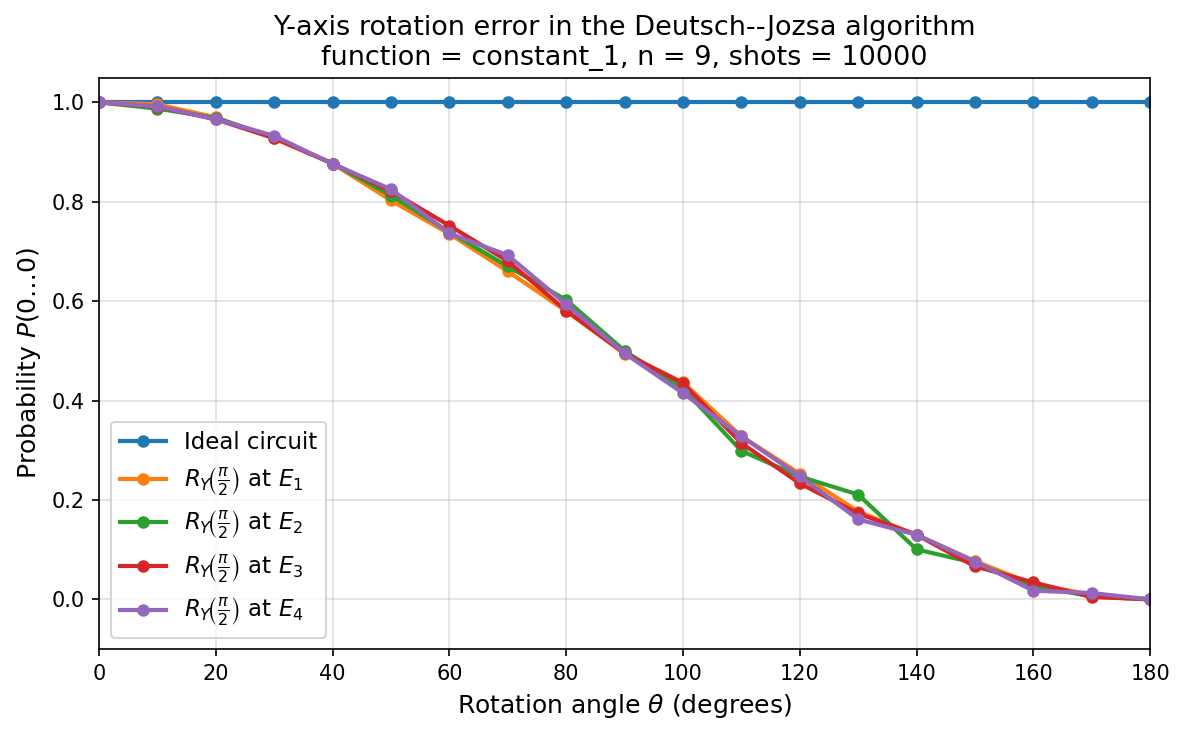

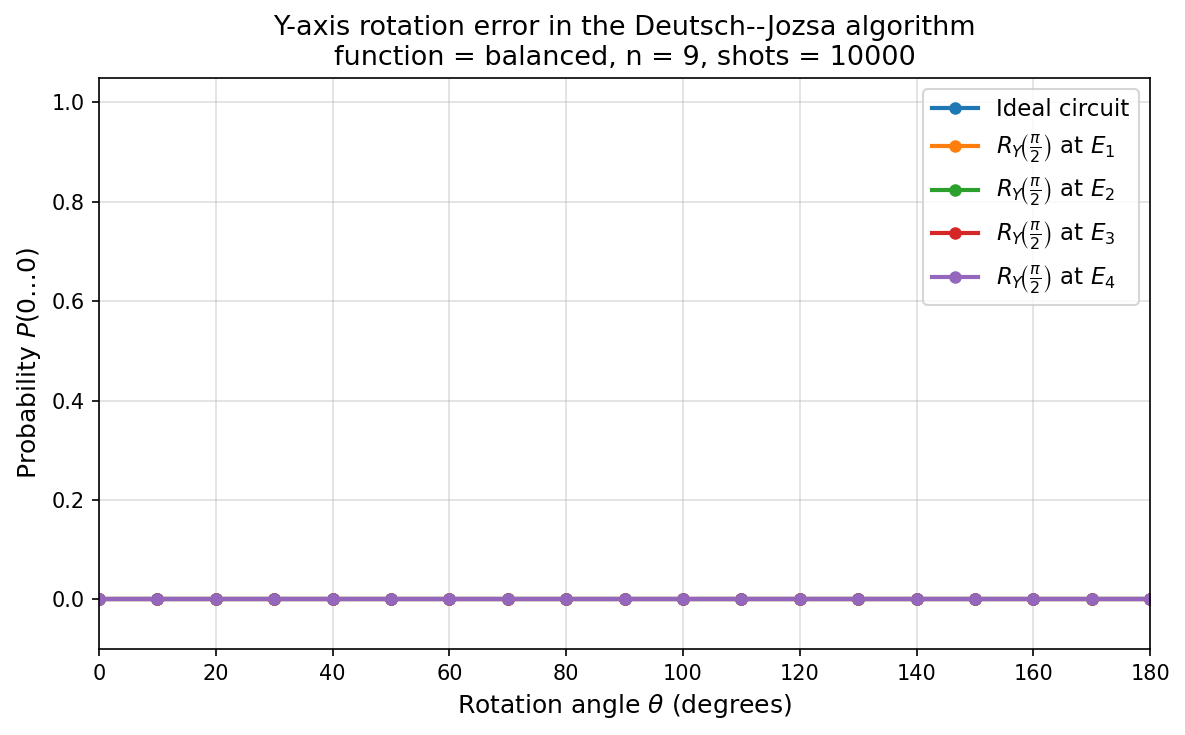

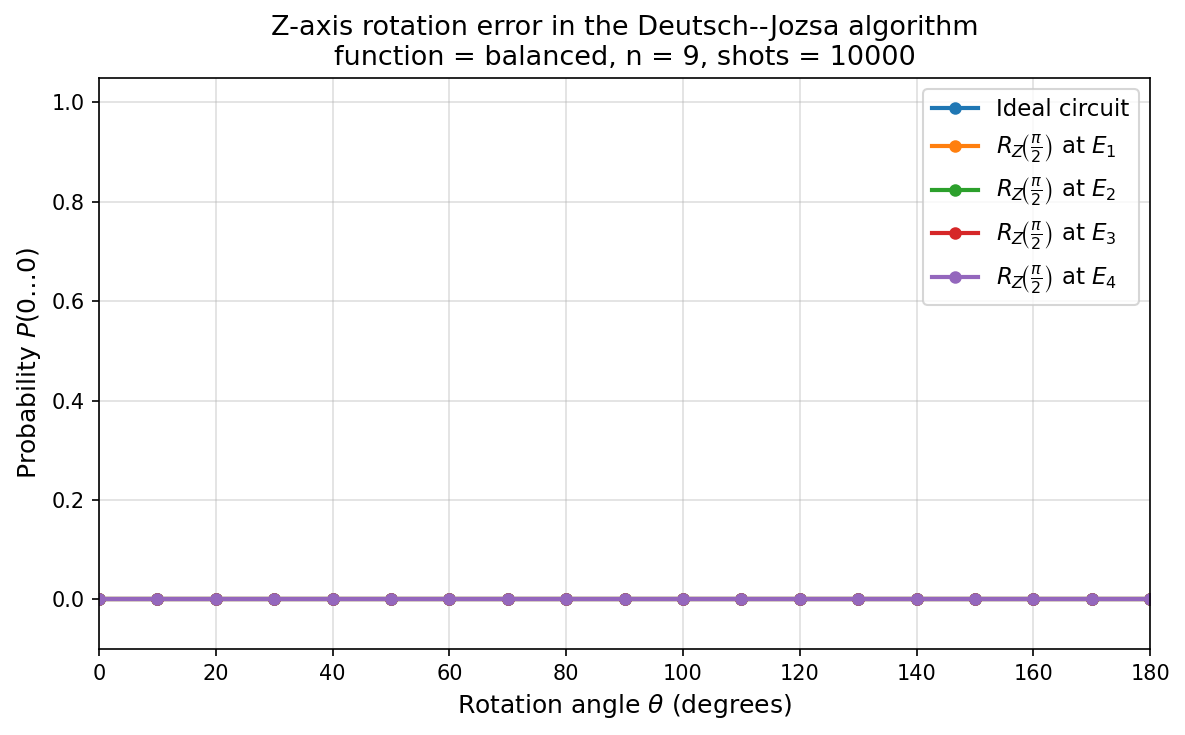

In [17]:
qa.plotting.plot_error_positions(
    df,
    n_plot=9,
    axis_plot="Y",
    function_plot="constant_1",
    shots=10000
)

qa.plotting.plot_error_positions(
    df,
    n_plot=9,
    axis_plot="Y",
    function_plot="balanced",
    shots=10000
)

qa.plotting.plot_error_positions(
    df,
    n_plot=9,
    axis_plot="Z",
    function_plot="balanced",
    shots=10000
)

The experiment investigates the effect of single-qubit rotation errors on the Deutsch–Jozsa Algorithm. Four error positions were considered: E1 before the first Hadamard gates, E2 after the first Hadamard gates, E3 after the oracle, and E4 after the final Hadamard gates. The rotation angle θ was varied from 0° to 180° in steps of 10°. For each circuit configuration, 1024 measurement shots were used to estimate the probability of measuring the all-zero input state.

The number of input qubits was selected as n = 1, 3, 5, 7, and 9. This interval provides a feasible range for simulation while still showing how the algorithm behaves as the system size increases. The middle qubit was selected as the target qubit for the rotation error. Results were collected for X, Y, and Z rotation axes and for both a constant function and a balanced parity function.

For the ideal Deutsch–Jozsa Algorithm, the constant function should produce a high probability of measuring the all-zero state, while the balanced function should produce a low probability of measuring the all-zero state. Any deviation from this ideal behaviour indicates how strongly the corresponding error position affects the algorithm.
